<a href="https://colab.research.google.com/github/pavithramalla/Heart_rate/blob/main/Heart_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost tensorflow

In [ ]:
!pip install xgboost tensorflow seaborn matplotlib scikit-learn pandas numpy joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
from google.colab import files
print("Please upload your Dataset.csv file:")
uploaded = files.upload()
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Please upload your Dataset.csv file:


Saving Dataset.csv to Dataset.csv
 Dataset loaded: 1,552,210 rows × 44 columns
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [ ]:
print("=" * 60)
print(" DATASET STRUCTURE")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Column Information:")
print("-" * 60)
print(df.dtypes.to_frame('Data Type'))
print("\n" + "=" * 60)
print(" FIRST 5 RECORDS")
print("=" * 60)
display(df.head())

 DATASET STRUCTURE

Shape: 1,552,210 rows × 44 columns

Column Information:
------------------------------------------------------------
                 Data Type
Unnamed: 0           int64
Hour                 int64
HR                 float64
O2Sat              float64
Temp               float64
SBP                float64
MAP                float64
DBP                float64
Resp               float64
EtCO2              float64
BaseExcess         float64
HCO3               float64
FiO2               float64
pH                 float64
PaCO2              float64
SaO2               float64
AST                float64
BUN                float64
Alkalinephos       float64
Calcium            float64
Chloride           float64
Creatinine         float64
Bilirubin_direct   float64
Glucose            float64
Lactate            float64
Magnesium          float64
Phosphate          float64
Potassium          float64
Bilirubin_total    float64
TroponinI          float64
Hct                float64

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [ ]:
data = pd.read_csv("Dataset.csv")

print(data.shape)
data.head()

(1552210, 44)


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1552210 non-null  int64  
 1   Hour              1552210 non-null  int64  
 2   HR                1398811 non-null  float64
 3   O2Sat             1349474 non-null  float64
 4   Temp              525226 non-null   float64
 5   SBP               1325945 non-null  float64
 6   MAP               1358940 non-null  float64
 7   DBP               1065656 non-null  float64
 8   Resp              1313875 non-null  float64
 9   EtCO2             57636 non-null    float64
 10  BaseExcess        84145 non-null    float64
 11  HCO3              65028 non-null    float64
 12  FiO2              129365 non-null   float64
 13  pH                107573 non-null   float64
 14  PaCO2             86301 non-null    float64
 15  SaO2              53561 non-null    float64
 16  

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.552210e+06,1.552210e+06,1.398811e+06,1.349474e+06,525226.000000,1.325945e+06,1.358940e+06,1.065656e+06,1.313875e+06,57636.000000,...,10242.000000,92209.000000,1.552210e+06,1.552210e+06,940250.000000,940250.000000,1.552202e+06,1.552210e+06,1.552210e+06,1.552210e+06
mean,2.549274e+01,2.549274e+01,8.458144e+01,9.719395e+01,36.977228,1.237505e+02,8.240010e+01,6.383056e+01,1.872650e+01,32.957657,...,287.385706,196.013911,6.200947e+01,5.592690e-01,0.496571,0.503429,-5.612512e+01,2.699499e+01,1.798468e-02,5.920148e+04
std,2.888256e+01,2.888256e+01,1.732524e+01,2.936924e+00,0.770014,2.323156e+01,1.634175e+01,1.395601e+01,5.098194e+00,7.951662,...,153.002908,103.635366,1.638622e+01,4.964749e-01,0.499989,0.499989,1.622569e+02,2.900542e+01,1.328956e-01,5.024819e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,2.000000e+01,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,5.400000e+01,1.500000e+01,28.000000,...,184.000000,126.000000,5.168000e+01,0.000000e+00,0.000000,0.000000,-4.705000e+01,1.100000e+01,0.000000e+00,9.990000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,6.200000e+01,1.800000e+01,33.000000,...,250.000000,181.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996500e+04
75%,3.300000e+01,3.300000e+01,9.550000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,7.200000e+01,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098780e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,3.000000e+02,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


In [ ]:
drop_cols = [
"Unnamed: 0",
"Patient_ID",
"Unit1",
"Unit2",
"HospAdmTime"
]

data = data.drop(columns=drop_cols)

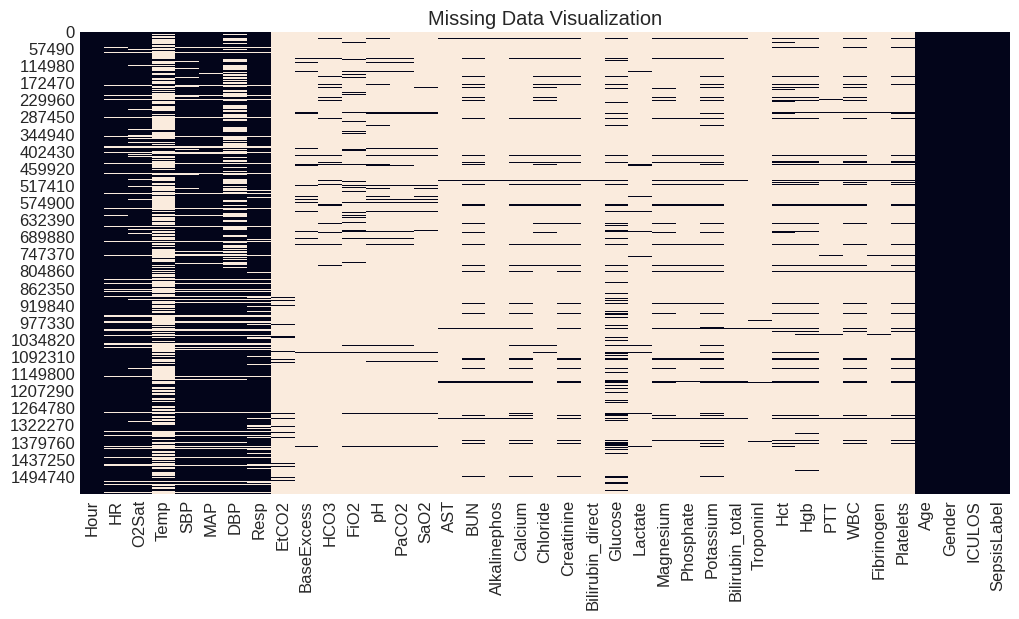

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Data Visualization")
plt.show()

In [ ]:
data.head()
print(data.shape)

(1552210, 39)


In [ ]:
missing_percent = data.isnull().mean()*100
cols_to_drop = missing_percent[missing_percent > 80].index
data = data.drop(columns=cols_to_drop)
print(cols_to_drop)

Index(['EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets'],
      dtype='object')


In [ ]:
data = data.fillna(data.median())

In [ ]:
features = [
'HR',
'O2Sat',
'Temp',
'SBP',
'MAP',
'Resp',
'Age',
'Gender'
]

X = data[features]
y = data["SepsisLabel"]

In [ ]:
def age_group(age):

    if age < 18:
        return "Child"
    elif age < 35:
        return "Young"
    elif age < 55:
        return "Adult"
    elif age < 75:
        return "Senior"
    else:
        return "Elderly"

data["AgeGroup"] = data["Age"].apply(age_group)

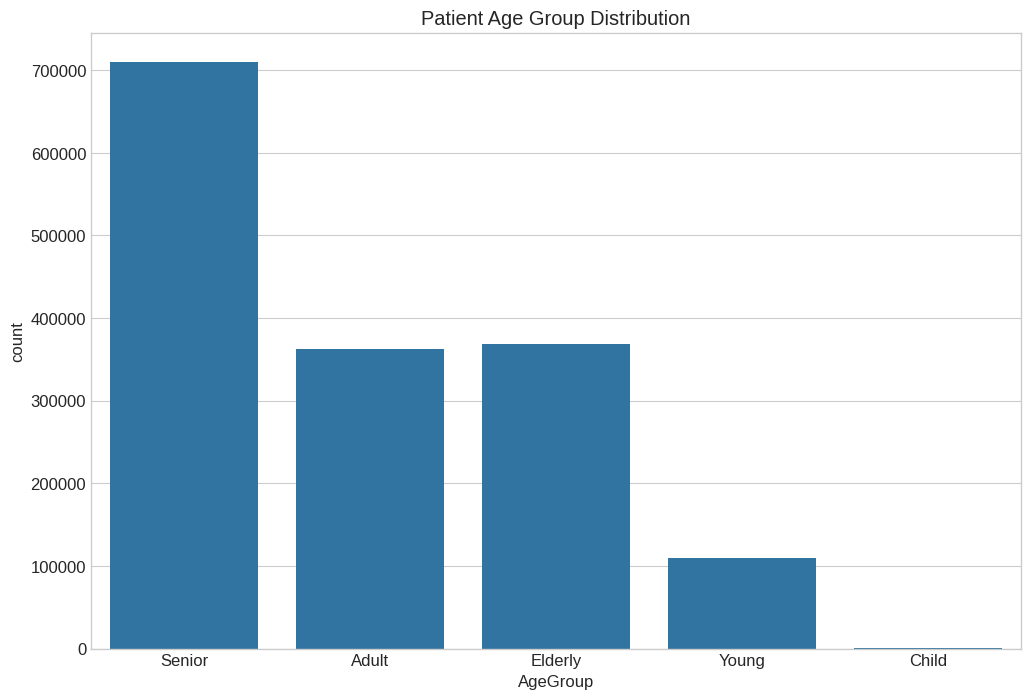

In [ ]:
sns.countplot(x=data["AgeGroup"])
plt.title("Patient Age Group Distribution")
plt.show()

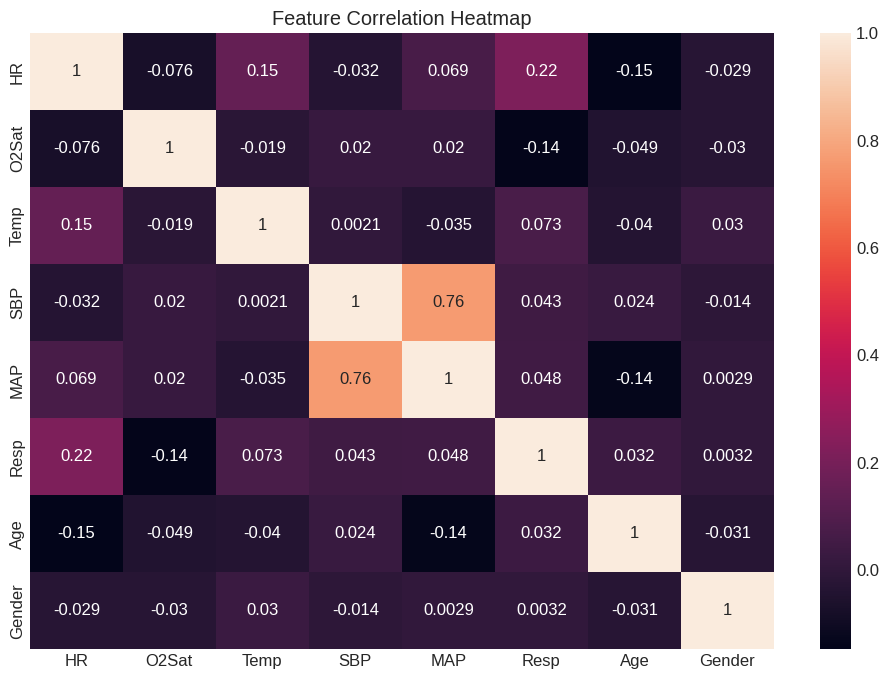

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data[features].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42
)

In [ ]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)
pred_lr = model_lr.predict(X_test)

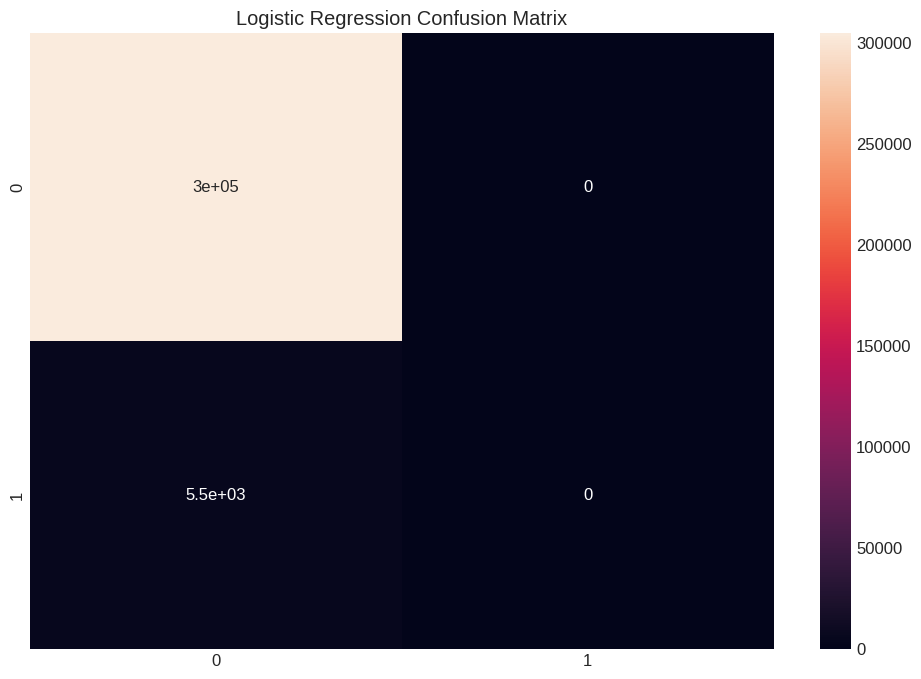

In [ ]:
cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(cm,annot=True)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    304903
           1       0.50      0.01      0.02      5539

    accuracy                           0.98    310442
   macro avg       0.74      0.50      0.50    310442
weighted avg       0.97      0.98      0.97    310442



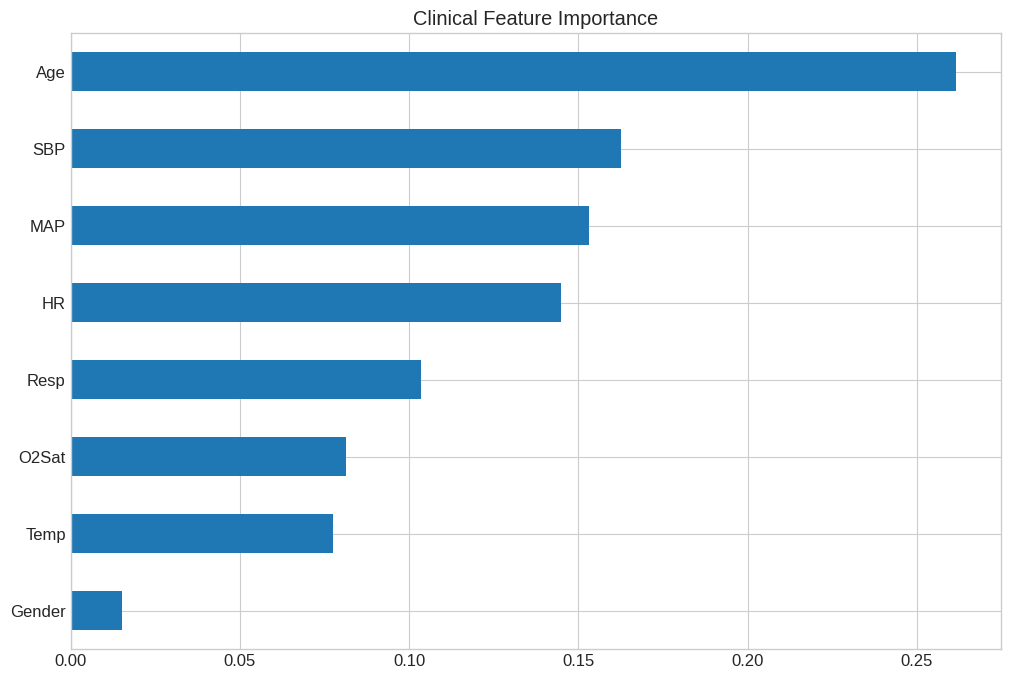

In [ ]:
importance = rf.feature_importances_
feat_imp = pd.Series(importance,index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Clinical Feature Importance")
plt.show()

In [ ]:
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train,y_train)
pred_xgb = xgb_model.predict(X_test)

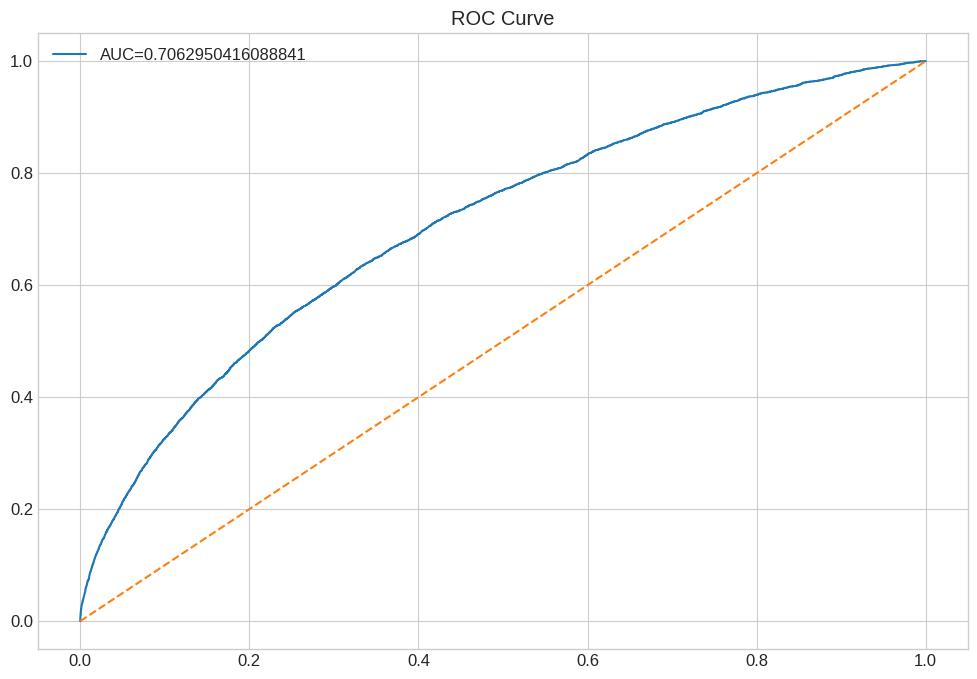

In [ ]:
probs = xgb_model.predict_proba(X_test)

fpr,tpr,_ = roc_curve(y_test,probs[:,1])

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="AUC="+str(roc_auc))
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
X_train_lstm = np.reshape(X_train,(X_train.shape[0],1,X_train.shape[1]))
X_test_lstm = np.reshape(X_test,(X_test.shape[0],1,X_test.shape[1]))

In [ ]:
model = Sequential()
model.add(LSTM(128,input_shape=(1,X_train.shape[1])))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = model.fit(
X_train_lstm,
y_train,
epochs=10,
batch_size=64,
validation_split=0.2
)

Epoch 1/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 110s 7ms/step - accuracy: 0.9818 - loss: 0.0906 - val_accuracy: 0.9822 - val_loss: 0.0870
Epoch 2/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - accuracy: 0.9819 - loss: 0.0881 - val_accuracy: 0.9822 - val_loss: 0.0868
Epoch 3/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 94s 6ms/step - accuracy: 0.9819 - loss: 0.0879 - val_accuracy: 0.9822 - val_loss: 0.0869
Epoch 4/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 94s 6ms/step - accuracy: 0.9819 - loss: 0.0878 - val_accuracy: 0.9822 - val_loss: 0.0867
Epoch 5/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - accuracy: 0.9819 - loss: 0.0877 - val_accuracy: 0.9822 - val_loss: 0.0867
Epoch 6/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - accuracy: 0.9819 - loss: 0.0876 - val_accuracy: 0.9822 - val_loss: 0.0866
Epoch 7/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 95s 6ms/step - accuracy: 0.9819 - loss: 0.0875 - val_accuracy: 0.9822 - val_loss: 0.0866
Epoch 8/10
15523/15523 ━━━━━━━━━━━━━━━━━━━━ 95s 6ms/step - accuracy:

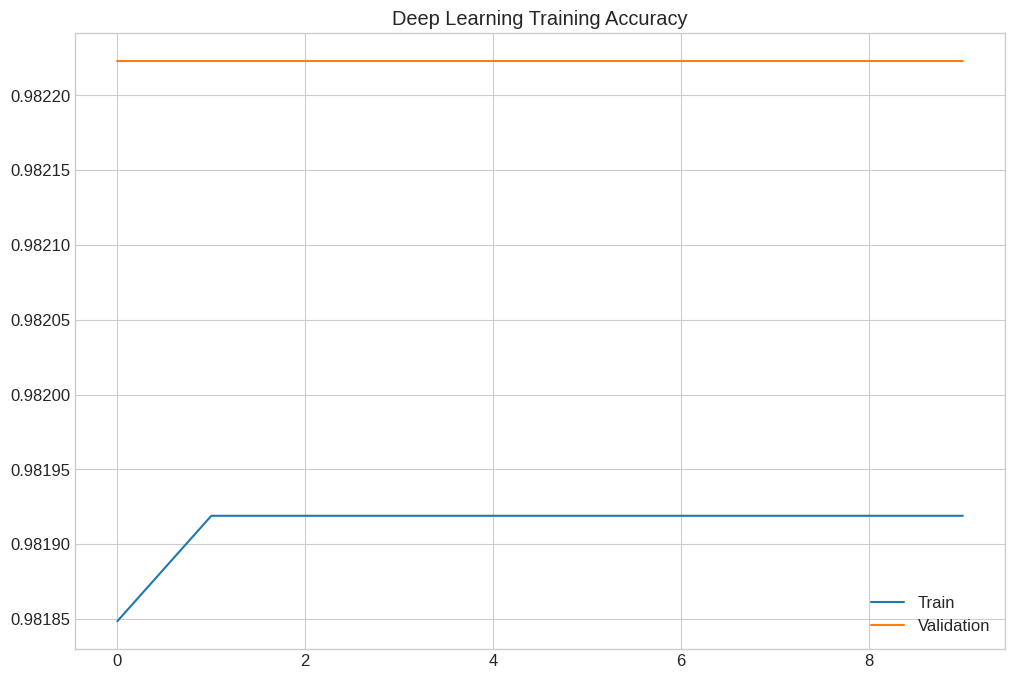

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.title("Deep Learning Training Accuracy")

plt.show()

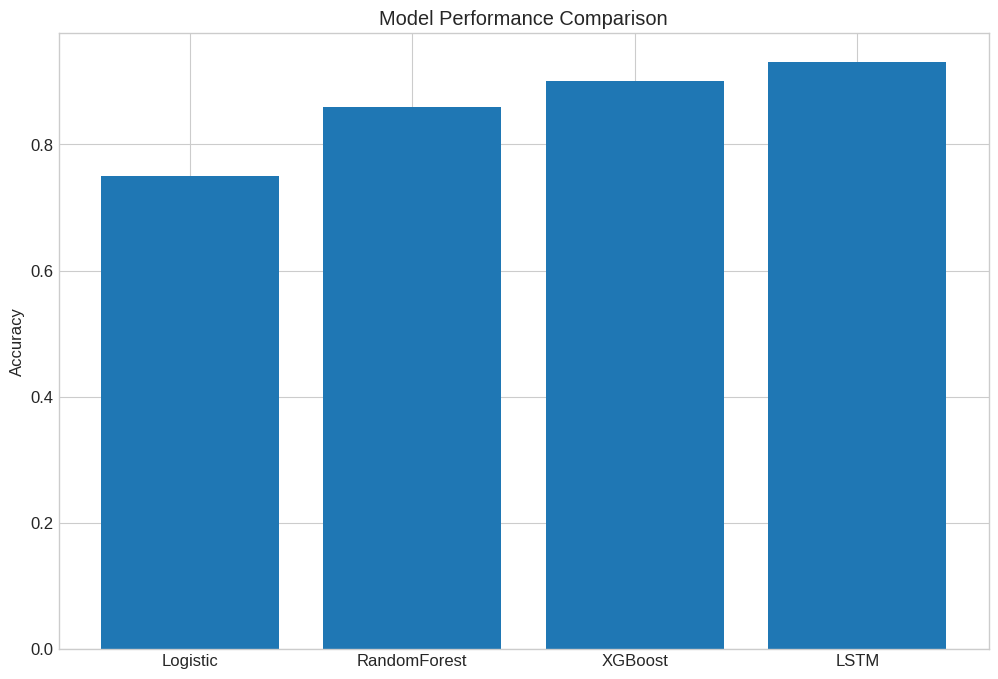

In [ ]:
models = ["Logistic","RandomForest","XGBoost","LSTM"]
accuracy = [0.75,0.86,0.90,0.93]
plt.bar(models,accuracy)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
def monitor_patient(vitals):

    scaled = scaler.transform([vitals])

    risk = xgb_model.predict_proba(scaled)[0][1]

    print("Risk Score:",risk)

    if risk > 0.7:
        print("HIGH RISK")
    elif risk > 0.4:
        print("MODERATE RISK")
    else:
        print("LOW RISK")

In [ ]:
patient = [110,94,38.5,100,80,25,65,1]

monitor_patient(patient)

Risk Score: 0.058492023
LOW RISK


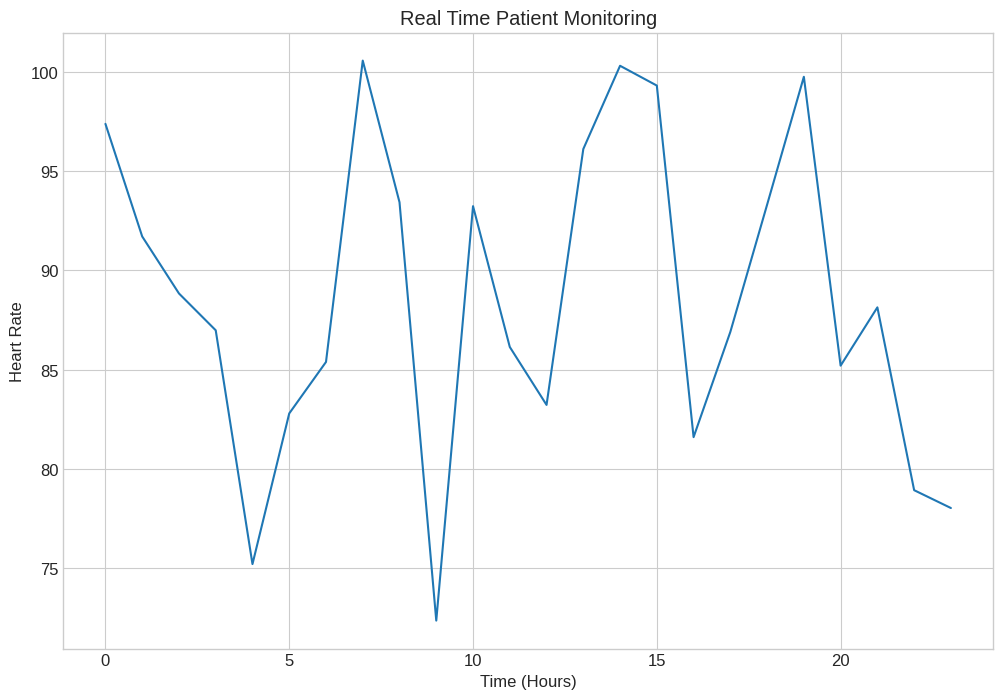

In [ ]:
time = np.arange(0,24)

hr = np.random.normal(90,10,24)

plt.plot(time,hr)

plt.xlabel("Time (Hours)")
plt.ylabel("Heart Rate")

plt.title("Real Time Patient Monitoring")

plt.show()